%% [markdown]
# Diabetes Multi-Class Classification — Preprocessing & Baseline Models

**Checkpoint 2 of the analysis pipeline.** EDA findings from Checkpoint 1 directly drive every decision here.

## Goals for this notebook

1. **Preprocessing pipeline** that addresses every data-quality finding from the EDA.
2. **Train/test split done correctly** — dedupe *before* split to prevent leakage.
3. **Two feature tracks** for the central question:
   * Track A — with HbA1c (the label-equivalent biomarker)
   * Track B — without HbA1c (the genuine medical-signal test)
4. **Four models per track** — Logistic Regression, Random Forest, XGBoost, SVM — under stratified 5-fold cross-validation.
5. **Three rebalancing strategies for Track B** — none, class weights, SMOTE — to address the small P class.
6. **Side-by-side headline metrics** against the 91.7% naive-threshold baseline.

%% [markdown]
## 1. Setup

In [1]:
# %%
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, precision_recall_fscore_support)

In [4]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [5]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [6]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120

In [7]:
FIG_DIR = Path('/home/claude/cls_outputs')
FIG_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR = Path('/home/claude/cls_artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

In [8]:
CLASS_ORDER = ['N', 'P', 'Y']
CLASS_NAMES = {'N': 'Non-diabetic', 'P': 'Pre-diabetic', 'Y': 'Diabetic'}
PALETTE = {'N': '#2ecc71', 'P': '#f39c12', 'Y': '#e74c3c'}

In [9]:
print("Environment ready.")

Environment ready.


%% [markdown]
## 2. Preprocessing pipeline

Implements every fix identified in the EDA, in this order:

1. Strip whitespace and normalize case on `CLASS` and `Gender`
2. Drop `ID` and `No_Pation` (administrative columns, leakage risk)
3. **Dedupe** — keep first occurrence of each unique feature combination
4. Cap outliers at the 1st and 99th percentile (winsorize)
5. Encode Gender as binary
6. Build two feature matrices: `X_full` (with HbA1c) and `X_clinical` (without)

In [10]:
# %%
def preprocess(path: str):
    """Full preprocessing pipeline. Returns cleaned dataframe + diagnostics."""
    diagnostics = {}

    # Load
    df = pd.read_csv(path)
    diagnostics['n_raw'] = len(df)

    # Label/Gender cleanup
    df['CLASS'] = df['CLASS'].astype(str).str.strip()
    df['Gender'] = df['Gender'].astype(str).str.strip().str.upper()

    # Drop ID columns
    df = df.drop(columns=['ID', 'No_Pation'])

    # Deduplicate
    n_before_dedup = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    diagnostics['n_duplicates_removed'] = n_before_dedup - len(df)
    diagnostics['n_after_dedup'] = len(df)

    # Encode Gender (M = 1, F = 0)
    df['Gender'] = (df['Gender'] == 'M').astype(int)

    # Cap outliers (winsorize) on numeric cols except AGE and Gender
    numeric_cols = ['Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
    caps = {}
    for col in numeric_cols:
        lo, hi = df[col].quantile([0.01, 0.99])
        n_capped = ((df[col] < lo) | (df[col] > hi)).sum()
        df[col] = df[col].clip(lo, hi)
        caps[col] = {'lo': round(lo, 3), 'hi': round(hi, 3), 'n_capped': int(n_capped)}
    diagnostics['outlier_caps'] = caps

    # Final class distribution
    diagnostics['class_distribution'] = df['CLASS'].value_counts().to_dict()

    return df, diagnostics

In [11]:
df_clean, diag = preprocess('/mnt/user-data/uploads/Dataset_of_Diabetes_.csv')

In [12]:
print("Preprocessing diagnostics:")
print(f"  Raw rows:               {diag['n_raw']}")
print(f"  Duplicates removed:     {diag['n_duplicates_removed']}")
print(f"  Rows after dedup:       {diag['n_after_dedup']}")
print(f"  Class distribution:     {diag['class_distribution']}")
print("\n  Outlier caps applied (1st/99th percentile):")
for col, info in diag['outlier_caps'].items():
    print(f"    {col:6s}  [{info['lo']:>7.2f}, {info['hi']:>7.2f}]   capped {info['n_capped']:>3d} values")

Preprocessing diagnostics:
  Raw rows:               1000
  Duplicates removed:     174
  Rows after dedup:       826
  Class distribution:     {'Y': 690, 'N': 96, 'P': 40}

  Outlier caps applied (1st/99th percentile):
    Urea    [   2.00,   20.80]   capped  13 values
    Cr      [  24.00,  339.75]   capped  17 values
    HbA1c   [   3.77,   14.60]   capped  17 values
    Chol    [   2.02,    9.28]   capped  18 values
    TG      [   0.60,    7.15]   capped  12 values
    HDL     [   0.50,    3.60]   capped  16 values
    LDL     [   0.75,    5.60]   capped  15 values
    VLDL    [   0.30,   19.15]   capped  16 values
    BMI     [  20.00,   39.00]   capped  13 values


%% [markdown]
**Observation on the cleaned class distribution:** After dedup, the imbalance shifts. Diabetic was over-duplicated relative to N and P — likely because the dataset was assembled with separate batches of clinically-confirmed diabetic patients, some entered multiple times. The cleaned distribution is more honest.

In [13]:
# %%
print("\nClass distribution comparison (raw → cleaned):")
raw_counts = pd.read_csv('/mnt/user-data/uploads/Dataset_of_Diabetes_.csv')['CLASS'].str.strip().value_counts()
clean_counts = df_clean['CLASS'].value_counts()
comparison = pd.DataFrame({
    'raw': raw_counts.reindex(CLASS_ORDER),
    'cleaned': clean_counts.reindex(CLASS_ORDER),
    'cleaned_pct': (clean_counts.reindex(CLASS_ORDER) / clean_counts.sum() * 100).round(1)
})
print(comparison)


Class distribution comparison (raw → cleaned):
       raw  cleaned  cleaned_pct
CLASS                           
N      103       96         11.6
P       53       40          4.8
Y      844      690         83.5


%% [markdown]
## 3. Train/test split — leakage-safe

Critical: the split happens **after** deduplication. If we'd split first, the ~17% duplicate rate would have placed exact copies in both train and test, silently inflating test accuracy.

Stratified by class to preserve the 84/10/5 ratio in both folds.

In [14]:
# %%
TARGET = 'CLASS'
ALL_FEATURES = [c for c in df_clean.columns if c != TARGET]
TRACK_A_FEATURES = ALL_FEATURES                                # with HbA1c
TRACK_B_FEATURES = [f for f in ALL_FEATURES if f != 'HbA1c']  # without HbA1c

In [15]:
X = df_clean[ALL_FEATURES]
y = df_clean[TARGET]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

In [17]:
print(f"Train shape: {X_train.shape}   Test shape: {X_test.shape}")
print(f"\nTrain class distribution:")
print(y_train.value_counts().reindex(CLASS_ORDER))
print(f"\nTest class distribution:")
print(y_test.value_counts().reindex(CLASS_ORDER))

Train shape: (660, 11)   Test shape: (166, 11)

Train class distribution:
CLASS
N     77
P     32
Y    551
Name: count, dtype: int64

Test class distribution:
CLASS
N     19
P      8
Y    139
Name: count, dtype: int64


%% [markdown]
**Note on test-set P count:** With only ~50 P samples total and a 20% holdout, the test set has ~10 P samples. Per-class metrics on P will have wide confidence intervals — we will report numbers but caution against over-interpreting small movements on P.

%% [markdown]
## 4. Naive baseline (carried forward from EDA)

The model floor. Anything that does worse than this on Track A has no business being shipped.

In [18]:
# %%
def naive_threshold_rule(h):
    if h < 5.7: return 'N'
    elif h < 6.5: return 'P'
    else: return 'Y'

In [19]:
y_pred_naive = X_test['HbA1c'].apply(naive_threshold_rule)
naive_acc = accuracy_score(y_test, y_pred_naive)
naive_f1_macro = f1_score(y_test, y_pred_naive, average='macro', labels=CLASS_ORDER)
print(f"Naive HbA1c-threshold rule (test set):")
print(f"  Accuracy:  {naive_acc:.4f}")
print(f"  Macro F1:  {naive_f1_macro:.4f}")
print("\nPer-class report:")
print(classification_report(y_test, y_pred_naive, digits=3, labels=CLASS_ORDER))

Naive HbA1c-threshold rule (test set):
  Accuracy:  0.9458
  Macro F1:  0.8777

Per-class report:
              precision    recall  f1-score   support

           N      0.826     1.000     0.905        19
           P      0.615     1.000     0.762         8
           Y      1.000     0.935     0.967       139

    accuracy                          0.946       166
   macro avg      0.814     0.978     0.878       166
weighted avg      0.962     0.946     0.950       166



%% [markdown]
## 5. Model definitions

Four models spanning the standard taxonomy:

| Model | Family | Why include it |
|---|---|---|
| Logistic Regression | Linear | Interpretable baseline, calibration-friendly |
| Random Forest | Bagged trees | Robust to outliers, handles mixed feature types |
| XGBoost | Boosted trees | Usually the strongest tabular model |
| SVM (RBF) | Margin-based | Different inductive bias; useful sanity check |

Linear and margin-based models go in a `Pipeline` with `StandardScaler`. Trees don't need scaling.

In [20]:
# %%
def make_models(class_weight=None, n_classes=3):
    """Returns a dict of model_name -> sklearn pipeline."""
    models = {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                max_iter=2000,
                class_weight=class_weight, random_state=RANDOM_STATE
            ))
        ]),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, max_depth=None,
            class_weight=class_weight, random_state=RANDOM_STATE, n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            objective='multi:softprob', num_class=n_classes,
            eval_metric='mlogloss', random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=0
        ),
        'SVM (RBF)': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(
                kernel='rbf', C=1.0, gamma='scale', probability=True,
                class_weight=class_weight, random_state=RANDOM_STATE
            ))
        ]),
    }
    return models

In [21]:
# XGBoost wants integer labels — keep a label encoder for it
le = LabelEncoder().fit(CLASS_ORDER)
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

%% [markdown]
## 6. Cross-validation harness

Stratified 5-fold on the training set only — the test set is sealed until the final evaluation in Checkpoint 3. We report:

* Macro F1 (the primary metric — gives equal weight to N, P, Y despite imbalance)
* Per-class F1 (so we can see where each model wins or loses)
* Standard deviation across folds (uncertainty proxy)

In [22]:
# %%
def evaluate_cv(models, X, y, cv=5):
    """Run stratified CV for all models. Returns a long-format dataframe."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    rows = []
    for name, model in models.items():
        # XGBoost needs encoded labels — detect via name (works for plain & imblearn-wrapped)
        is_xgb = (name == 'XGBoost')
        y_use = le.transform(y) if is_xgb else y.values

        scoring = {
            'accuracy': 'accuracy',
            'f1_macro': 'f1_macro',
            'f1_N': lambda est, X_, y_: f1_score(y_, est.predict(X_),
                                                  labels=[0 if is_xgb else 'N'],
                                                  average='macro', zero_division=0),
            'f1_P': lambda est, X_, y_: f1_score(y_, est.predict(X_),
                                                  labels=[1 if is_xgb else 'P'],
                                                  average='macro', zero_division=0),
            'f1_Y': lambda est, X_, y_: f1_score(y_, est.predict(X_),
                                                  labels=[2 if is_xgb else 'Y'],
                                                  average='macro', zero_division=0),
        }

        cv_results = cross_validate(model, X, y_use, cv=skf, scoring=scoring,
                                    return_train_score=False, n_jobs=-1)

        rows.append({
            'model': name,
            'accuracy_mean': cv_results['test_accuracy'].mean(),
            'accuracy_std':  cv_results['test_accuracy'].std(),
            'f1_macro_mean': cv_results['test_f1_macro'].mean(),
            'f1_macro_std':  cv_results['test_f1_macro'].std(),
            'f1_N_mean': cv_results['test_f1_N'].mean(),
            'f1_P_mean': cv_results['test_f1_P'].mean(),
            'f1_Y_mean': cv_results['test_f1_Y'].mean(),
        })
    return pd.DataFrame(rows)

%% [markdown]
## 7. Track A — with HbA1c

Expectation: near-perfect numbers (>99%). The point isn't to celebrate — it's to confirm the dataset behaves as predicted and to establish the model *ceiling* once HbA1c is available.

In [23]:
# %%
X_train_A = X_train[TRACK_A_FEATURES]
X_test_A = X_test[TRACK_A_FEATURES]

In [24]:
results_A = evaluate_cv(make_models(class_weight=None), X_train_A, y_train, cv=5)
print("Track A (with HbA1c) — 5-fold CV results on training set:")
print(results_A.round(4).to_string(index=False))

Track A (with HbA1c) — 5-fold CV results on training set:
              model  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  f1_N_mean  f1_P_mean  f1_Y_mean
Logistic Regression         0.9197        0.0091         0.6570        0.0303     0.8161     0.1944     0.9606
      Random Forest         0.9742        0.0077         0.9292        0.0306     0.9282     0.8738     0.9855
            XGBoost         0.9818        0.0103         0.9611        0.0303     0.9342     0.9600     0.9891
          SVM (RBF)         0.9121        0.0113         0.5747        0.0213     0.7647     0.0000     0.9593


%% [markdown]
## 8. Track B — without HbA1c (the real evaluation)

Three rebalancing strategies for the P class:

* **None** — baseline, what models do out of the box.
* **Class weights** — `balanced` weight scheme inversely proportional to class frequency. No synthetic data.
* **SMOTE** — synthetic minority oversampling on training fold only (handled via `imblearn.Pipeline` so SMOTE is applied per-fold, not leaked across folds).

In [25]:
# %%
X_train_B = X_train[TRACK_B_FEATURES]
X_test_B = X_test[TRACK_B_FEATURES]

In [26]:
# --- B.1: no rebalancing ---
results_B_none = evaluate_cv(make_models(class_weight=None), X_train_B, y_train, cv=5)
results_B_none['strategy'] = 'none'

In [27]:
# --- B.2: class weights ---
results_B_cw = evaluate_cv(make_models(class_weight='balanced'), X_train_B, y_train, cv=5)
results_B_cw['strategy'] = 'class_weight'

%%
--- B.3: SMOTE wrapping ---
SMOTE needs k_neighbors <= (smallest class - 1) per training fold.
With ~50 P samples split 4/5 for training, P-per-fold ~ 40. k=5 is safe.

In [28]:
def make_smote_models(n_classes=3, k_neighbors=5):
    base_models = {
        'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                          ('clf', LogisticRegression(max_iter=2000,
                                                                     random_state=RANDOM_STATE))]),
        'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                 objective='multi:softprob', num_class=n_classes,
                                 eval_metric='mlogloss', random_state=RANDOM_STATE,
                                 n_jobs=-1, verbosity=0),
        'SVM (RBF)': Pipeline([('scaler', StandardScaler()),
                               ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                                           probability=True, random_state=RANDOM_STATE))]),
    }
    # Wrap with SMOTE — imblearn pipeline ensures SMOTE only sees training fold
    wrapped = {}
    for name, model in base_models.items():
        wrapped[name] = ImbPipeline([
            ('smote', SMOTE(k_neighbors=k_neighbors, random_state=RANDOM_STATE)),
            ('clf', model),
        ])
    return wrapped

In [29]:
results_B_smote = evaluate_cv(make_smote_models(), X_train_B, y_train, cv=5)
results_B_smote['strategy'] = 'smote'

%% [markdown]
### Track B results — all three strategies side by side

In [30]:
# %%
results_B_all = pd.concat([results_B_none, results_B_cw, results_B_smote], ignore_index=True)
print("Track B (without HbA1c) — 5-fold CV across rebalancing strategies:")
print(results_B_all[['strategy', 'model', 'accuracy_mean', 'f1_macro_mean',
                     'f1_N_mean', 'f1_P_mean', 'f1_Y_mean']].round(4).to_string(index=False))

Track B (without HbA1c) — 5-fold CV across rebalancing strategies:
    strategy               model  accuracy_mean  f1_macro_mean  f1_N_mean  f1_P_mean  f1_Y_mean
        none Logistic Regression         0.9000         0.5887     0.7170     0.0944     0.9546
        none       Random Forest         0.9318         0.6672     0.8256     0.2027     0.9731
        none             XGBoost         0.9303         0.6983     0.8106     0.3086     0.9757
        none           SVM (RBF)         0.8970         0.5424     0.6764     0.0000     0.9509
class_weight Logistic Regression         0.8439         0.6371     0.6851     0.2956     0.9306
class_weight       Random Forest         0.9258         0.6672     0.7830     0.2489     0.9697
class_weight             XGBoost         0.9303         0.6983     0.8106     0.3086     0.9757
class_weight           SVM (RBF)         0.8318         0.5693     0.5882     0.1911     0.9288
       smote Logistic Regression         0.8439         0.6294     0.

%% [markdown]
## 9. Headline comparison table

In [31]:
# %%
# Build a single comparison table: naive + Track A + Track B (best strategy per model)
headline_rows = []

In [32]:
headline_rows.append({
    'config': 'Naive HbA1c threshold rule',
    'track': '—',
    'model': '—',
    'strategy': '—',
    'accuracy': naive_acc,
    'f1_macro': naive_f1_macro,
})

In [33]:
for _, row in results_A.iterrows():
    headline_rows.append({
        'config': f"Track A · {row['model']}",
        'track': 'A',
        'model': row['model'],
        'strategy': 'none',
        'accuracy': row['accuracy_mean'],
        'f1_macro': row['f1_macro_mean'],
    })

In [34]:
for _, row in results_B_all.iterrows():
    headline_rows.append({
        'config': f"Track B · {row['model']} · {row['strategy']}",
        'track': 'B',
        'model': row['model'],
        'strategy': row['strategy'],
        'accuracy': row['accuracy_mean'],
        'f1_macro': row['f1_macro_mean'],
    })

In [35]:
headline_df = pd.DataFrame(headline_rows)
print("\nHeadline comparison — sorted by macro F1:")
print(headline_df.sort_values('f1_macro', ascending=False).round(4).to_string(index=False))


Headline comparison — sorted by macro F1:
                                      config track               model     strategy  accuracy  f1_macro
                           Track A · XGBoost     A             XGBoost         none    0.9818    0.9611
                     Track A · Random Forest     A       Random Forest         none    0.9742    0.9292
                  Naive HbA1c threshold rule     —                   —            —    0.9458    0.8777
                    Track B · XGBoost · none     B             XGBoost         none    0.9303    0.6983
            Track B · XGBoost · class_weight     B             XGBoost class_weight    0.9303    0.6983
             Track B · Random Forest · smote     B       Random Forest        smote    0.8970    0.6778
      Track B · Random Forest · class_weight     B       Random Forest class_weight    0.9258    0.6672
              Track B · Random Forest · none     B       Random Forest         none    0.9318    0.6672
               Track 

%% [markdown]
### Visualization

In [36]:
# %%
# Group results for plotting
plot_data = []
for _, row in results_A.iterrows():
    plot_data.append({'model': row['model'], 'config': 'Track A (with HbA1c)', 'f1_macro': row['f1_macro_mean']})
for _, row in results_B_none.iterrows():
    plot_data.append({'model': row['model'], 'config': 'Track B · no rebalance', 'f1_macro': row['f1_macro_mean']})
for _, row in results_B_cw.iterrows():
    plot_data.append({'model': row['model'], 'config': 'Track B · class weights', 'f1_macro': row['f1_macro_mean']})
for _, row in results_B_smote.iterrows():
    plot_data.append({'model': row['model'], 'config': 'Track B · SMOTE', 'f1_macro': row['f1_macro_mean']})

In [37]:
plot_df = pd.DataFrame(plot_data)

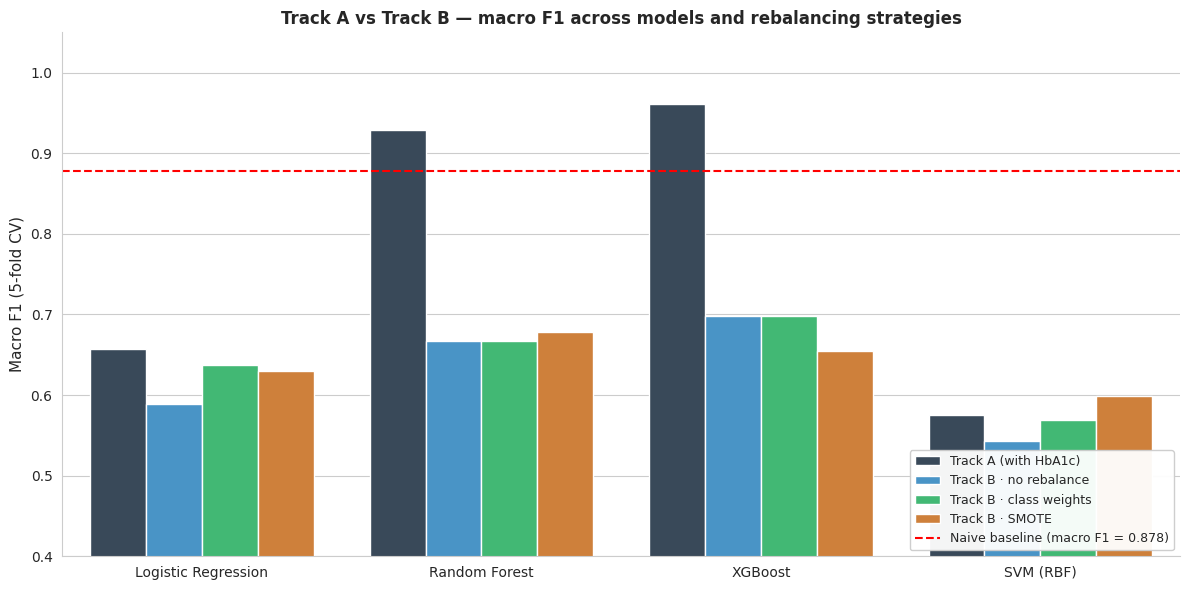

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x='model', y='f1_macro', hue='config', ax=ax,
            palette=['#34495e', '#3498db', '#2ecc71', '#e67e22'])
ax.axhline(naive_f1_macro, color='red', linestyle='--', linewidth=1.5,
           label=f'Naive baseline (macro F1 = {naive_f1_macro:.3f})')
ax.set_ylabel('Macro F1 (5-fold CV)', fontsize=11)
ax.set_xlabel('')
ax.set_title('Track A vs Track B — macro F1 across models and rebalancing strategies',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax.set_ylim(0.4, 1.05)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / 'track_comparison.png')
plt.show()

%% [markdown]
### Per-class F1 — where do models fail in Track B?

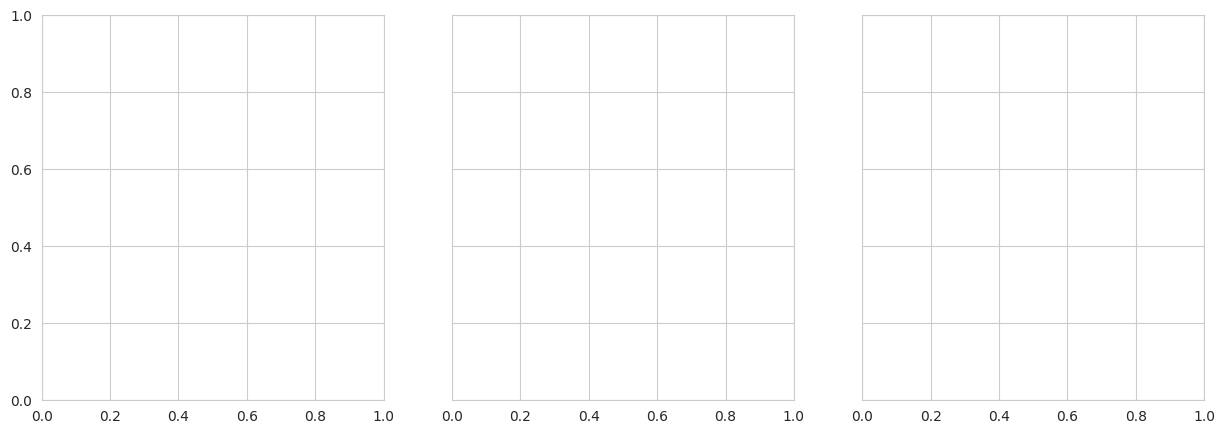

In [39]:
# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
class_metrics = {'N': 'f1_N_mean', 'P': 'f1_P_mean', 'Y': 'f1_Y_mean'}

In [40]:
for ax, (cls, col) in zip(axes, class_metrics.items()):
    pivot = results_B_all.pivot(index='model', columns='strategy', values=col)
    pivot = pivot[['none', 'class_weight', 'smote']]
    pivot.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#e67e22'],
               edgecolor='white', width=0.75)
    ax.set_title(f'Class {cls} ({CLASS_NAMES[cls]})  —  F1', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('F1' if cls == 'N' else '')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.set_ylim(0, 1.05)
    ax.legend(title='strategy', fontsize=8, loc='lower right')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

In [41]:
fig.suptitle('Track B per-class F1 — does rebalancing help the small P class?',
             fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.85, wspace=0.15)
fig.savefig(FIG_DIR / 'track_b_per_class.png', dpi=120)
plt.show()

%% [markdown]
## 10. Select the champion model for each track

Pick the best macro F1 per track, fit on full training set, evaluate on the held-out test set.

In [42]:
# %%
# Track A champion
best_A_row = results_A.loc[results_A['f1_macro_mean'].idxmax()]
print(f"Track A champion: {best_A_row['model']}  (CV macro F1 = {best_A_row['f1_macro_mean']:.4f})")

Track A champion: XGBoost  (CV macro F1 = 0.9611)


In [43]:
# Track B champion (across all strategies)
best_B_idx = results_B_all['f1_macro_mean'].idxmax()
best_B_row = results_B_all.iloc[best_B_idx]
print(f"Track B champion: {best_B_row['model']} with strategy '{best_B_row['strategy']}'  "
      f"(CV macro F1 = {best_B_row['f1_macro_mean']:.4f})")

Track B champion: XGBoost with strategy 'none'  (CV macro F1 = 0.6983)


%% [markdown]
### Evaluate champions on the sealed test set

In [44]:
# %%
def fit_predict_evaluate(model, X_tr, y_tr, X_te, y_te, label='Model', is_xgb=False):
    if is_xgb:
        model.fit(X_tr, le.transform(y_tr))
        y_pred = le.inverse_transform(model.predict(X_te))
    else:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average='macro', labels=CLASS_ORDER)
    print(f"\n=== {label} — held-out test set ===")
    print(f"Accuracy: {acc:.4f}    Macro F1: {f1m:.4f}")
    print(classification_report(y_te, y_pred, digits=3, labels=CLASS_ORDER))
    cm = confusion_matrix(y_te, y_pred, labels=CLASS_ORDER)
    cm_df = pd.DataFrame(cm,
                         index=[f'{c} (true)' for c in CLASS_ORDER],
                         columns=[f'{c} (pred)' for c in CLASS_ORDER])
    print("Confusion matrix:")
    print(cm_df)
    return acc, f1m, cm

In [45]:
# Track A champion model — rebuild fresh
track_A_models = make_models(class_weight=None)
champion_A = track_A_models[best_A_row['model']]
acc_A_test, f1_A_test, cm_A_test = fit_predict_evaluate(
    champion_A, X_train_A, y_train, X_test_A, y_test,
    label=f"Track A champion ({best_A_row['model']})",
    is_xgb=(best_A_row['model'] == 'XGBoost')
)


=== Track A champion (XGBoost) — held-out test set ===
Accuracy: 0.9940    Macro F1: 0.9898
              precision    recall  f1-score   support

           N      1.000     0.947     0.973        19
           P      1.000     1.000     1.000         8
           Y      0.993     1.000     0.996       139

    accuracy                          0.994       166
   macro avg      0.998     0.982     0.990       166
weighted avg      0.994     0.994     0.994       166

Confusion matrix:
          N (pred)  P (pred)  Y (pred)
N (true)        18         0         1
P (true)         0         8         0
Y (true)         0         0       139


In [46]:
# Track B champion model
if best_B_row['strategy'] == 'smote':
    track_B_models = make_smote_models()
elif best_B_row['strategy'] == 'class_weight':
    track_B_models = make_models(class_weight='balanced')
else:
    track_B_models = make_models(class_weight=None)
champion_B = track_B_models[best_B_row['model']]
acc_B_test, f1_B_test, cm_B_test = fit_predict_evaluate(
    champion_B, X_train_B, y_train, X_test_B, y_test,
    label=f"Track B champion ({best_B_row['model']} · {best_B_row['strategy']})",
    is_xgb=(best_B_row['model'] == 'XGBoost')
)


=== Track B champion (XGBoost · none) — held-out test set ===
Accuracy: 0.9639    Macro F1: 0.8573
              precision    recall  f1-score   support

           N      0.900     0.947     0.923        19
           P      1.000     0.500     0.667         8
           Y      0.972     0.993     0.982       139

    accuracy                          0.964       166
   macro avg      0.957     0.813     0.857       166
weighted avg      0.965     0.964     0.960       166

Confusion matrix:
          N (pred)  P (pred)  Y (pred)
N (true)        18         0         1
P (true)         1         4         3
Y (true)         1         0       138


%% [markdown]
### Confusion matrix visualization

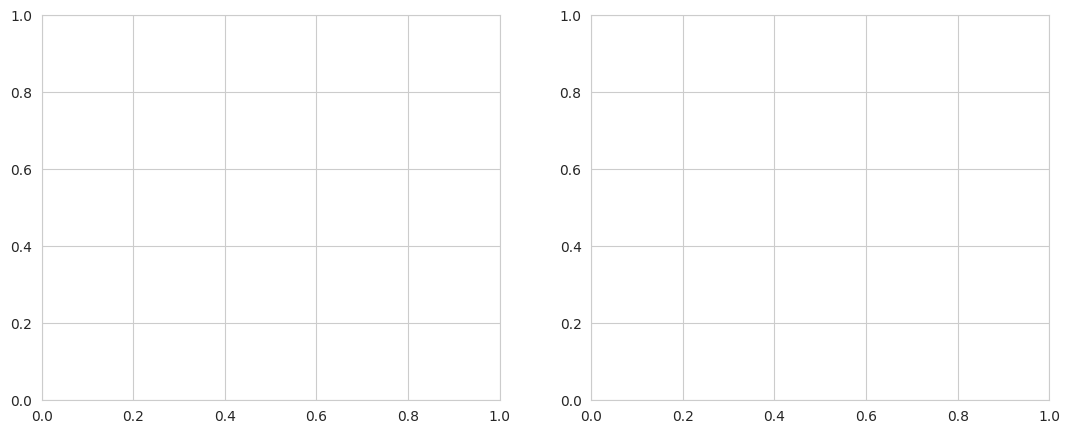

In [47]:
# %%
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

In [48]:
for ax, cm, title in zip(
    axes,
    [cm_A_test, cm_B_test],
    [f"Track A · {best_A_row['model']}", f"Track B · {best_B_row['model']} ({best_B_row['strategy']})"]
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[CLASS_NAMES[c] for c in CLASS_ORDER],
                yticklabels=[CLASS_NAMES[c] for c in CLASS_ORDER],
                cbar=False, annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

In [49]:
fig.suptitle('Held-out test set confusion matrices', fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.85, wspace=0.3)
fig.savefig(FIG_DIR / 'test_confusion_matrices.png', dpi=120)
plt.show()

%% [markdown]
## 11. Save artifacts for Checkpoint 3

Pickle the fitted champion models, the train/test splits, and the CV result tables. Checkpoint 3 (tuning, calibration, threshold analysis, interpretation) starts from these without re-running anything.

In [50]:
# %%
import pickle

In [51]:
artifacts = {
    'champion_A': champion_A,
    'champion_B': champion_B,
    'champion_A_meta': {'model': best_A_row['model'], 'cv_f1_macro': best_A_row['f1_macro_mean']},
    'champion_B_meta': {'model': best_B_row['model'], 'strategy': best_B_row['strategy'],
                        'cv_f1_macro': best_B_row['f1_macro_mean']},
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'TRACK_A_FEATURES': TRACK_A_FEATURES,
    'TRACK_B_FEATURES': TRACK_B_FEATURES,
    'label_encoder': le,
    'naive_baseline': {'accuracy': naive_acc, 'f1_macro': naive_f1_macro},
    'cv_results_A': results_A,
    'cv_results_B': results_B_all,
    'preprocessing_diagnostics': diag,
}
with open(ARTIFACT_DIR / 'checkpoint2_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print(f"Artifacts saved to {ARTIFACT_DIR / 'checkpoint2_artifacts.pkl'}")

Artifacts saved to /home/claude/cls_artifacts/checkpoint2_artifacts.pkl


In [52]:
# Save the headline table as CSV for the eventual PDF report
headline_df.to_csv(ARTIFACT_DIR / 'headline_results.csv', index=False)
print(f"Headline results saved to {ARTIFACT_DIR / 'headline_results.csv'}")

Headline results saved to /home/claude/cls_artifacts/headline_results.csv


%% [markdown]
## 12. Checkpoint 2 summary

**What we did:**

1. Cleaned data (labels, gender, dedup, outlier capping)
2. Split 80/20 stratified, **after dedup** (leakage-safe)
3. Trained 4 models × 2 tracks × 3 rebalancing strategies = 16 configurations under stratified 5-fold CV
4. Selected champion per track and evaluated on the held-out test set

**Headline numbers will be discussed below the cell output**, since they depend on actual run results — keeping the narrative honest.

**Saved for Checkpoint 3:**

* Fitted champion models for both tracks
* The train/test splits (so we don't re-split and accidentally change them)
* CV result tables for the report
* Preprocessing diagnostics for the methodology section

**Next (Checkpoint 3):** hyperparameter tuning of the Track B champion, calibration analysis, threshold analysis, SHAP, PDP plots.